# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.


| Groep: 01     |  |
| :-------------|:-------------|
| Korné Hoendervangers| 6466826 |
| Tijn Kraam| 6566499|
| Kristy Workel| 6483984 |
| Planning Groep: 01 |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | Condensator gemaakt en getest 12:45 |
|Eerste metingen aan sensor|15:30/16:00|
| Mijlpaal 2 | Sensor gemaakt en getest 17:00 |
| Harde deadline|17:30 opgeruimd en klaar|
| groep aanwezig 1| 10:45 - 12:45 |
| groep aanwezig 2| 13:45 - eind |
| Pauze 1| 1 uur om 12:45 |
| Pauze 2| 15 min 15:00 |


## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schets.jpg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)
epsilonR = 2.75
A = 0.01
def vlakkeplaat(d):
    C = ((epsilon0 *epsilonR* A) / (d*10**-3))*10**12
    return C


# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = [vlakkeplaat(2.0), vlakkeplaat(4.7),vlakkeplaat(1.2)]


print(f"Berekende capaciteit plaatcondensator groep 01 is {C[0]:.1f} pF")



Berekende capaciteit plaatcondensator groep 01 is 121.7 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](scope_test.jpg)
![scope meting 2](test_C.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 01| 122 pF |  6V | 0.72 V |143pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schetsen.jpg)


## Opdracht 3: Welke sensor gaan jullie maken?

Idee 1 waarbij we foam tussen de platen leggen om het verband tussen het indrukken en de capaciteit te meten.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](gedetaileerde_schets.jpg)

Bij dit onderwerp moesten we itereren. Waarbij we een nieuwe spons hebben genomen met een hoogte van 16 mm en 2 nieuwe platen met afmetingen 10cmx15cm. 

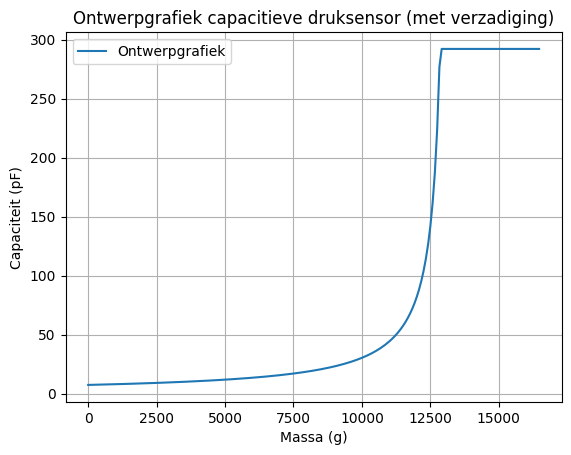

In [3]:
#oude ontwerpgrafiek
import numpy as np
import matplotlib.pyplot as plt

# Constanten
epsilon0 = 8.854e-12   # F/m
epsilonR = 1.1
A = 0.015              # m^2

# Afstanden (mm)
d0 = 20                # beginafstand
d_min = 0.5            # minimale afstand (mechanische stop!)

# Doorbuiging (mm)
doorbuiging = np.linspace(0, 25, 200)

# Effectieve plaatafstand met limiet
d = np.maximum(d0 - doorbuiging, d_min)

# Massa (kg → g)
k = 6464               # N/m (effectieve veerconstante)
Massa = (k * doorbuiging * 1e-3) / 9.81
Massa = Massa * 1000   # g

# Capaciteit
def vlakkeplaat2(d_mm):
    d_m = d_mm * 1e-3
    C = epsilon0 * epsilonR * A / d_m
    return C * 1e12     # pF

Capaciteit = vlakkeplaat2(d)

# Plot
plt.plot(Massa, Capaciteit, label='Ontwerpgrafiek')
plt.xlabel('Massa (g)')
plt.ylabel('Capaciteit (pF)')
plt.title('Ontwerpgrafiek capacitieve druksensor (met verzadiging)')
plt.grid()
plt.legend()
plt.show()

De grafiek hieronder is het effect dat je verwacht bij een weegschaal op basis van een condensator met als tussenstof een spons. Om een goed beeld te krijgen van hoe de indrukken van de spons zich gedraagt moet bepaald worden wat de rust afstand is tussen de platen en moet er een schatting gemaakt worden van de afstand als de spons vrijwel helemaal is ingedrukt. Doordat een spons meerdere fases heeft van indrukken moet er een factor bijkomen die deze fases kan bepalen. Dat gebeurt met de e macht die in d_x staat. Deze functie wordt uiteindelijk gefit om te bepalen hoe snel dat de spons indrukt. Daarnaast blijft de permitiviteit ook niet constant. Doordat de spons indrukt zal er lucht ontsnappen en blijft er na verhouding steeds meer spons over ten opzichte van lucht. Daarom wordt gebruik gemaakt van een functie die mee verandert wanneer afstand kleiner wordt. Dit gebeurt in de functie eps_eff. De d_x en eps_eff kunnen vervolgens in de standaart formule worden geplaatst om de capaciteit uit te rekenen.

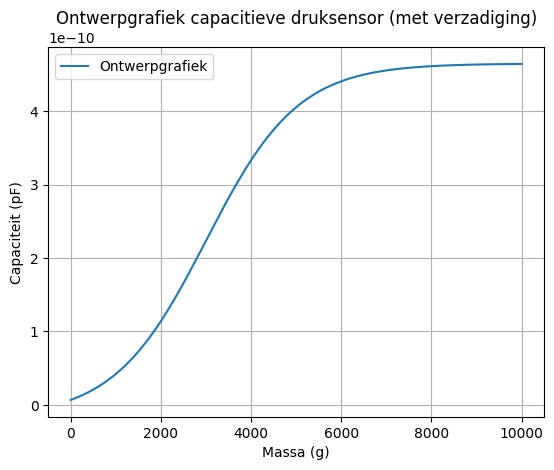

In [4]:
#nieuwe code ontwerpgrafiek:
import numpy as np
import matplotlib.pyplot as plt
#constanten
Epsilon0 = 8.854e-12   # F/m
Epsilon_lucht = 1
Epsilon_solid = 3.5
A = 0.015              # m^2
D_0 = 0.02                # beginafstand (mm)
g = 9.81
D_min = 0.001
def ontwerpfit(x,a):
    d_x = D_min + (D_0 - D_min) * np.exp(-a * x * g)
    vulgraad = (D_0 - d_x) / (D_0 - D_min)
    eps_eff = Epsilon_lucht + (Epsilon_solid - Epsilon_lucht) * vulgraad
    return (Epsilon0 * eps_eff * A) / d_x

x = np.linspace(0, 10000, 200)  # Massa (g)
a = 10**-4
b=2*10**-3
c=100
d=1
Capaciteit_ontwerp = ontwerpfit(x,a)
plt.figure()
plt.plot(x, Capaciteit_ontwerp, label='Ontwerpgrafiek')
plt.xlabel('Massa (g)')
plt.ylabel('Capaciteit (pF)')
plt.title('Ontwerpgrafiek capacitieve druksensor (met verzadiging)')
plt.grid()
plt.legend()
plt.show()


## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 36.5 |183.37 |
| gemiddelde capaciteit| 87.58 |436 |
| maximale capaciteit| 292.182 |1441 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](gewicht1.jpg)
![meting 2](scope1.jpg)
![meting 1](gewicht2.jpg)
![meting 2](scope2.jpg)

## Opdracht 7: Plot de kalibratiegrafiek.

We hebben in een veel kleiner bereik gemeten dan voorspellingsgrafiek. Waardoor we in het begin van de grafiek zitten, waar het verband lijkt op een s vorm. We fitten daarom andere formule die beter past bij het gevonden verband.

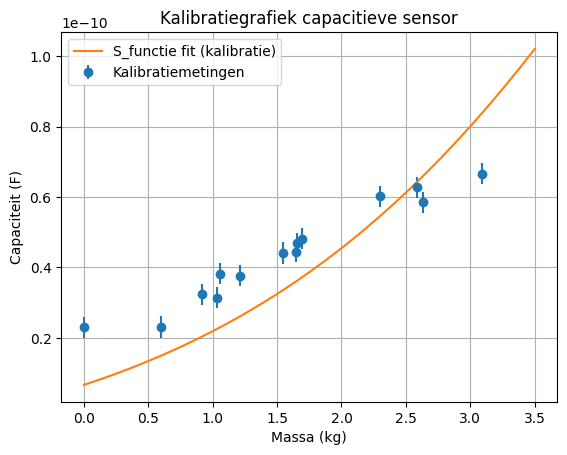

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Massa_kalibratie = np.array([0,600.3,1033,1692.4,3093.1,2635.3,1546.4,1060.8,919.5,1209.7,1643.3,2302.0,2589.1,1656.1])/1000

Capaciteit_kalibratie = np.array([23,23.1,31.4,48.2,66.6,58.5,44.1,38.2,32.4,37.6,44.5,60.2,62.8,46.9])*10**-12

onzekerheid_C = 3 *10**-12 # F

popt, pcov = curve_fit(ontwerpfit, Massa_kalibratie, Capaciteit_kalibratie)

m_plot = np.linspace(0, 3.500, 300)

plt.figure()
plt.errorbar(Massa_kalibratie, Capaciteit_kalibratie,yerr=onzekerheid_C, fmt='o', label='Kalibratiemetingen')
plt.plot(m_plot, ontwerpfit(m_plot, *popt),label='S_functie fit (kalibratie)')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (F)')
plt.title('Kalibratiegrafiek capacitieve sensor')
plt.grid()
plt.legend()
plt.show()


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* De sensor heeft een instabiel platform waar het gewicht op geplaatst wordt. Dus om dit te verbeteren kan een grotere spons gebruikt worden.
* Op dit domein is de onzekerheid in Capaciteit nog te groot om exacte uitspraken te doen dus meten met 

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](opstelling1.jpg)
![foto sensor](opstelling2.jpg)

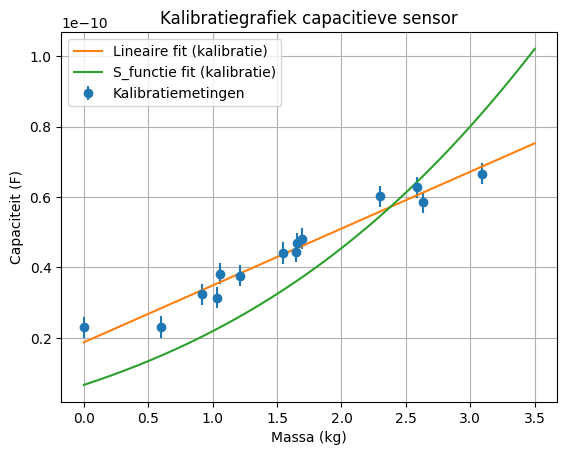

In [6]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
def lineairfit(x,a,b):
    return a*x + b
popt2, pcov2 = curve_fit(lineairfit, Massa_kalibratie, Capaciteit_kalibratie)
plt.figure()
plt.errorbar(Massa_kalibratie, Capaciteit_kalibratie,yerr=onzekerheid_C, fmt='o', label='Kalibratiemetingen')
plt.plot(m_plot, lineairfit(m_plot, *popt2), label='Lineaire fit (kalibratie)')
plt.plot(m_plot, ontwerpfit(m_plot, *popt),label='S_functie fit (kalibratie)')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (F)')
plt.title('Kalibratiegrafiek capacitieve sensor')
plt.grid()
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

In dit experiment hebben wij gekeken naar de verandering in C (de capaciteit van een condensator) bij verandering van massa. Hierbij hebben we gebruik gemaakt van een spons als tussengemaakt. De data die hierbij gemeten is, is gefit over de verwachte ontwerpgrafiek. Deze functie simuleert hoe een spons ingedrukt wordt. Echter deze geeft echter niet een mooie fit, dus is een betere fit gekozen waarbij gerbuik gemaakt wordt van een lineair verband. Onze verklaring voor het slecht passen van de S-functie is dat het domein waarover gemeten, [0,3] kg, te klein is om het verband goed te meten. Een ander probleem dat gevonden is op dit domein is de onzekerheid. Met onze opstelling is een constante onzekerheid vastgesteld van drie pF. Dit is een te grote onzekerheid om bij onze gevonden capaciteit een correcte uitspraak te doen. 

De conclusie is dan ook dat onze opstelling niet gebruikt kan worden om massa nauwkeurig te meten op dit domein. We kunnen voorspellen dat hogere waarden waarschijnlijk beter zouden kloppen, doordat onze onzekerheid rond de drie pF is gebleven bij elke meting. Om de metingen te verbeteren in vervolgonderzoeken zijn de stabiliteit van de opstelling en nauwkeurigheid de belangrijkste onderdelen. Dit kan vrij eenvoudig door een grotere spons als tussenmateriaal te gebruiken. De nauwkeurigheid zal het beste zijn in het gebied waar de steiging het grootste is. Doordat daar het verschil tussen capaciteiten het grootste is.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.
![foto sensor](schetsen.jpg)
![foto sensor](gedetaileerde_schets.jpg)
![foto sensor](kalibratiegrafiek.png)


kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.
![meting 1](gewicht1.jpg)
![meting 2](scope1.jpg)
![meting 1](gewicht2.jpg)
![meting 2](scope2.jpg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

![foto sensor](kalibratie_grafiek.png)
De grafiek met meetdata als 2 fits, zowel een lineaire als de s functie.
![foto sensor](kalibratie_grafiek2.png)
oude ontwerpgrafiek
![foto sensor](nieuwe_ontwerpgrafiek.png)
nieuwe ontwerpgrafiek

### conclusie


In dit experiment hebben wij gekeken naar de verandering in C (de capaciteit van een condensator) bij verandering van massa. Hierbij hebben we gebruik gemaakt van een spons als tussengemaakt. De data die hierbij gemeten is, is gefit over de verwachte ontwerpgrafiek. Deze functie simuleert hoe een spons ingedrukt wordt. Echter deze geeft echter niet een mooie fit, dus is een betere fit gekozen waarbij gerbuik gemaakt wordt van een lineair verband. Onze verklaring voor het slecht passen van de S-functie is dat het domein waarover gemeten, [0,3] kg, te klein is om het verband goed te meten. Een ander probleem dat gevonden is op dit domein is de onzekerheid. Met onze opstelling is een constante onzekerheid vastgesteld van drie pF. Dit is een te grote onzekerheid om bij onze gevonden capaciteit een correcte uitspraak te doen. 

De conclusie is dan ook dat onze opstelling niet gebruikt kan worden om massa nauwkeurig te meten op dit domein. We kunnen voorspellen dat hogere waarden waarschijnlijk beter zouden kloppen, doordat onze onzekerheid rond de drie pF is gebleven bij elke meting. Om de metingen te verbeteren in vervolgonderzoeken zijn de stabiliteit van de opstelling en nauwkeurigheid de belangrijkste onderdelen. Dit kan vrij eenvoudig door een grotere spons als tussenmateriaal te gebruiken. De nauwkeurigheid zal het beste zijn in het gebied waar de steiging het grootste is. Doordat daar het verschil tussen capaciteiten het grootste is.